# AB_S2.1 — Observed Metric Distribution Visualization

Explores how metric values behave across function families and relationship
categories — **before** the permutation test.

| Section | Question |
|---------|----------|
| 1. Function family fingerprints | How does each family (+ Null) distribute on each metric? |
| 2. Null baseline deep dive | Can we separate True Null from Variance-only? |
| 3. Category overview | How do the 4 relationship categories separate? |
| 4. Core metrics vs SNR | How does signal strength affect metric values? |
| 5. Metric correlation | Which metrics carry redundant vs. complementary information? |
| 6. Spread pattern effect | How does heteroscedasticity shape metric behavior? |
| 7. X-distribution influence | Does sampling density bias metric values? |


In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
%matplotlib inline

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')
VIZ_DIR = Path('output/S2/viz')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Load case metadata
cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_main['source'] = 'main'
cases_null['source'] = 'null_expanded'
offset = cases_main['case_id'].max()
cases_null['case_id'] = cases_null['case_id'] + offset
cases_df = pd.concat([cases_main, cases_null], ignore_index=True)

# Assign categories
is_null = cases_df['family_id'] == 'Null'
is_const = cases_df['spread_pattern'] == 'constant'
cases_df['category'] = 'mean+variance'
cases_df.loc[is_null & is_const, 'category'] = 'true_null'
cases_df.loc[~is_null & is_const, 'category'] = 'mean_only'
cases_df.loc[is_null & ~is_const, 'category'] = 'variance_only'

# Load metrics
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')
df = cases_df.merge(metrics, on='case_id', suffixes=('', '_m'))

print(f'Loaded {len(df):,} cases with {len(metrics.columns)} metric columns')
print(df['category'].value_counts())

Loaded 121,056 cases with 78 metric columns
category
mean+variance    85536
mean_only        28512
true_null         4032
variance_only     2976
Name: count, dtype: int64


In [2]:
CAT_ORDER = ['true_null', 'variance_only', 'mean_only', 'mean+variance']
CAT_COLORS = {'true_null': '#999999', 'variance_only': '#f59e0b',
              'mean_only': '#3b82f6', 'mean+variance': '#10b981'}
CAT_LABELS = {'true_null': 'True Null', 'variance_only': 'Variance-only',
              'mean_only': 'Mean-only', 'mean+variance': 'Mean+Variance'}

CORE_METRICS = ['pearson_r', 'spearman_rho', 'distance_correlation', 'MIC', 'ew_bin_eta_squared', 'lowess_r2']
CORE_LABELS = ['|Pearson r|', '|Spearman ρ|', 'Distance Correlation', 'MIC', 'η² (equal-width)', 'LOWESS R²']

# Use absolute values for correlation metrics
for col in ['pearson_r', 'spearman_rho']:
    if col in df.columns:
        df[col] = df[col].abs()

# Map eta_squared column name if needed
if 'equal_width_bin_eta_squared' in df.columns and 'ew_bin_eta_squared' not in df.columns:
    df['ew_bin_eta_squared'] = df['equal_width_bin_eta_squared']
if 'equal_count_bin_eta_squared' in df.columns and 'ec_bin_eta_squared' not in df.columns:
    df['ec_bin_eta_squared'] = df['equal_count_bin_eta_squared']

# Display-only axis limits based on the central 95% range.
# Raw metric values are unchanged. This only prevents a few extreme outliers from dominating the figure scale.
DISPLAY_QUANTILES = (0.025, 0.975)
NONNEGATIVE_METRICS = {'pearson_r', 'spearman_rho', 'distance_correlation', 'MIC', 'ew_bin_eta_squared'}

def _central_display_xlim(series, q=DISPLAY_QUANTILES, pad_frac=0.04):
    vals = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()
    if len(vals) == 0:
        return None
    lo, hi = vals.quantile(list(q)).values
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return None
    pad = (hi - lo) * pad_frac
    return float(lo - pad), float(hi + pad)

METRIC_XLIMS = {
    metric: _central_display_xlim(df[metric])
    for metric in CORE_METRICS
    if metric in df.columns
}
METRIC_XLIMS = {k: v for k, v in METRIC_XLIMS.items() if v is not None}
METRIC_XLIMS = {
    k: (max(0.0, v[0]), v[1]) if k in NONNEGATIVE_METRICS else v
    for k, v in METRIC_XLIMS.items()
}

def apply_metric_axis(ax, metric, axis='x'):
    if metric in METRIC_XLIMS:
        if axis == 'y':
            ax.set_ylim(*METRIC_XLIMS[metric])
        else:
            ax.set_xlim(*METRIC_XLIMS[metric])
        ax.text(0.98, 0.03, 'central 95% axis', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=7, color='#666666')

# --- Family short labels and TP-category color scheme ---
FAMILY_SHORT = {
    'F01': 'F01 Linear +',       'F02': 'F02 Linear −',
    'F03': 'F03 Power cvx +',    'F04': 'F04 Power cvx −',
    'F05': 'F05 Power ccv +',    'F06': 'F06 Power ccv −',
    'F07': 'F07 Saturation +',   'F08': 'F08 Saturation −',
    'F09': 'F09 Log +',          'F10': 'F10 Log −',
    'F11': 'F11 Exponential +',  'F12': 'F12 Exponential −',
    'F13': 'F13 S-curve +',      'F14': 'F14 S-curve −',
    'F15': 'F15 Threshold +',    'F16': 'F16 Threshold −',
    'F17': 'F17 Quad peak',      'F18': 'F18 Quad valley',
    'F19': 'F19 Spike',          'F20': 'F20 L-shaped',
    'F21': 'F21 Cubic',          'F22': 'F22 Complex',
    'Null (const σ)':  'Null (const σ)',
    'Null (varying σ)': 'Null (varying σ)',
}

# TP-based color mapping for family fingerprint plots
TP_MAP = {}
for i in range(1, 17):
    TP_MAP[f'F{i:02d}'] = '0 TP'
for i in range(17, 21):
    TP_MAP[f'F{i:02d}'] = '1 TP'
TP_MAP['F21'] = '2 TP'
TP_MAP['F22'] = 'Complex'
TP_MAP['Null (const σ)'] = 'Null'
TP_MAP['Null (varying σ)'] = 'Null (var)'

TP_COLORS = {
    '0 TP': '#3b82f6', '1 TP': '#f97316', '2 TP': '#22c55e',
    'Complex': '#a855f7', 'Null': '#9ca3af', 'Null (var)': '#f59e0b',
}

FAMILY_GROUP_ORDER = [f'F{i:02d}' for i in range(1, 23)] + ['Null (const σ)', 'Null (varying σ)']
FAMILY_GROUP_LABELS = [FAMILY_SHORT[g] for g in FAMILY_GROUP_ORDER]
FAMILY_GROUP_PALETTE = {FAMILY_SHORT[g]: TP_COLORS[TP_MAP[g]] for g in FAMILY_GROUP_ORDER}

## 1. Function Family Fingerprints

Horizontal boxplots showing how each of the 22 function families + 2 Null types
distribute on the 6 selected metrics.

- **Signal families (F01–F22)**: mean-only cases (constant spread) across all SNR,
  to isolate the mean-response signal without spread-pattern confounding.
- **Null (const σ)**: True Null cases — f(X)=0, σ(X)=constant.
- **Null (varying σ)**: Variance-only cases — f(X)=0, σ(X) varies with x.

Color indicates turning-point category:
🔵 0 TP (monotonic) · 🟠 1 TP · 🟢 2 TP · 🟣 Complex · ⬜ Null (const) · 🟡 Null (varying)

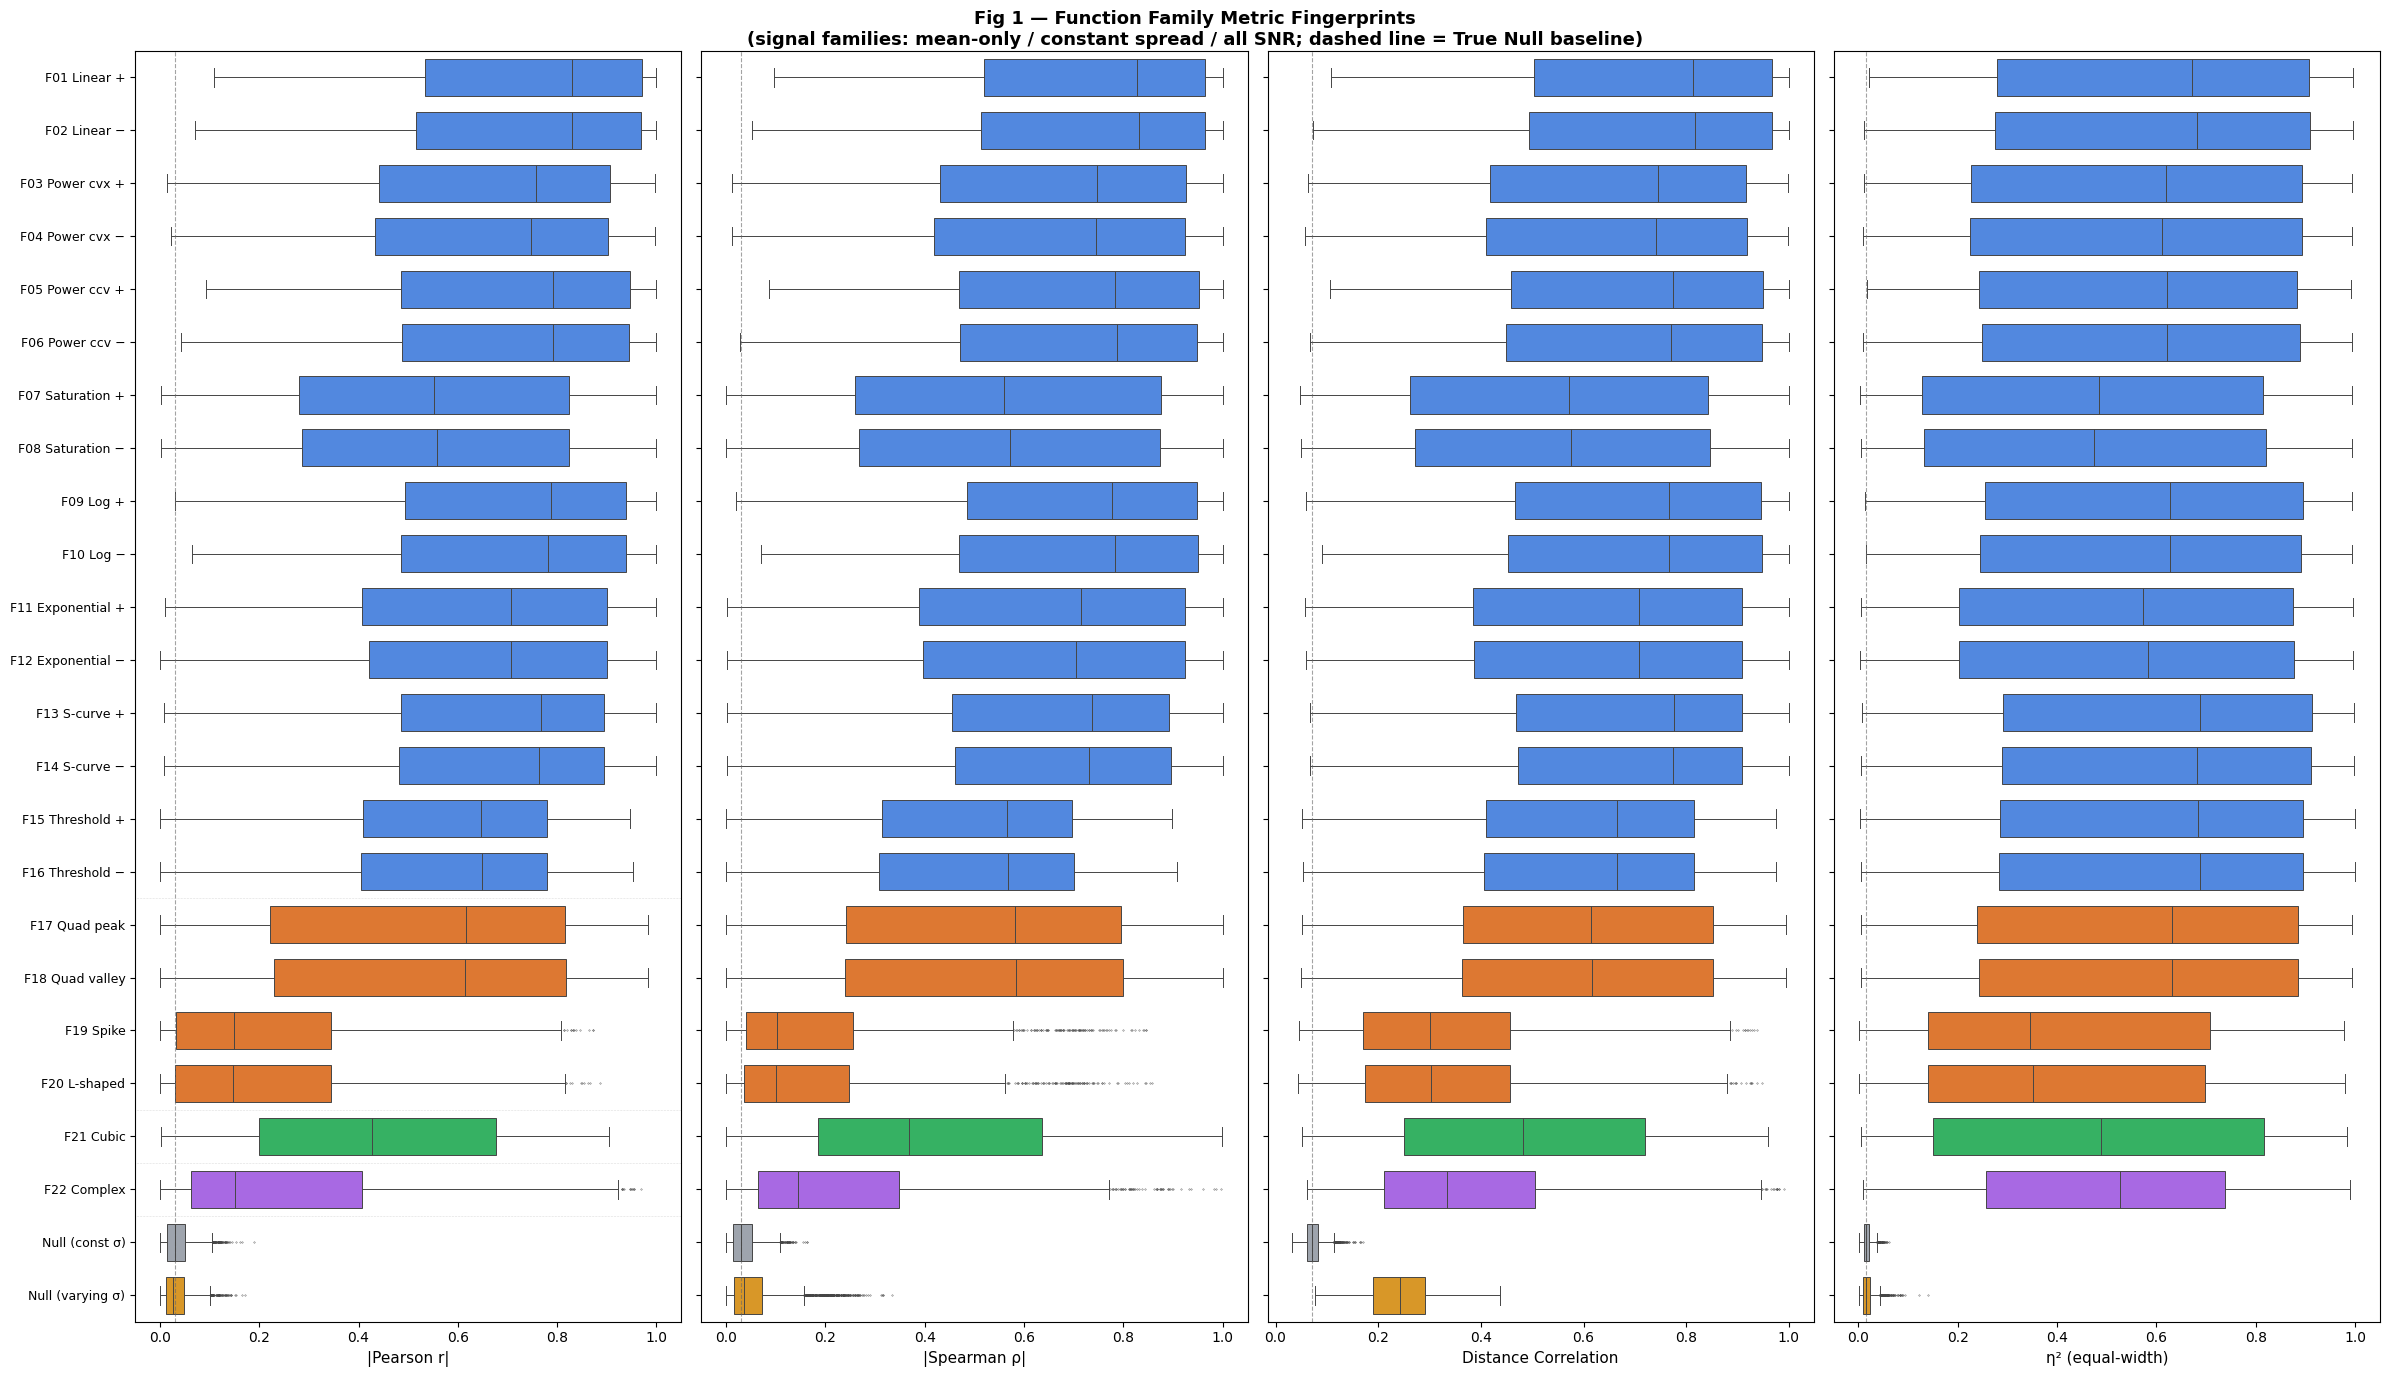

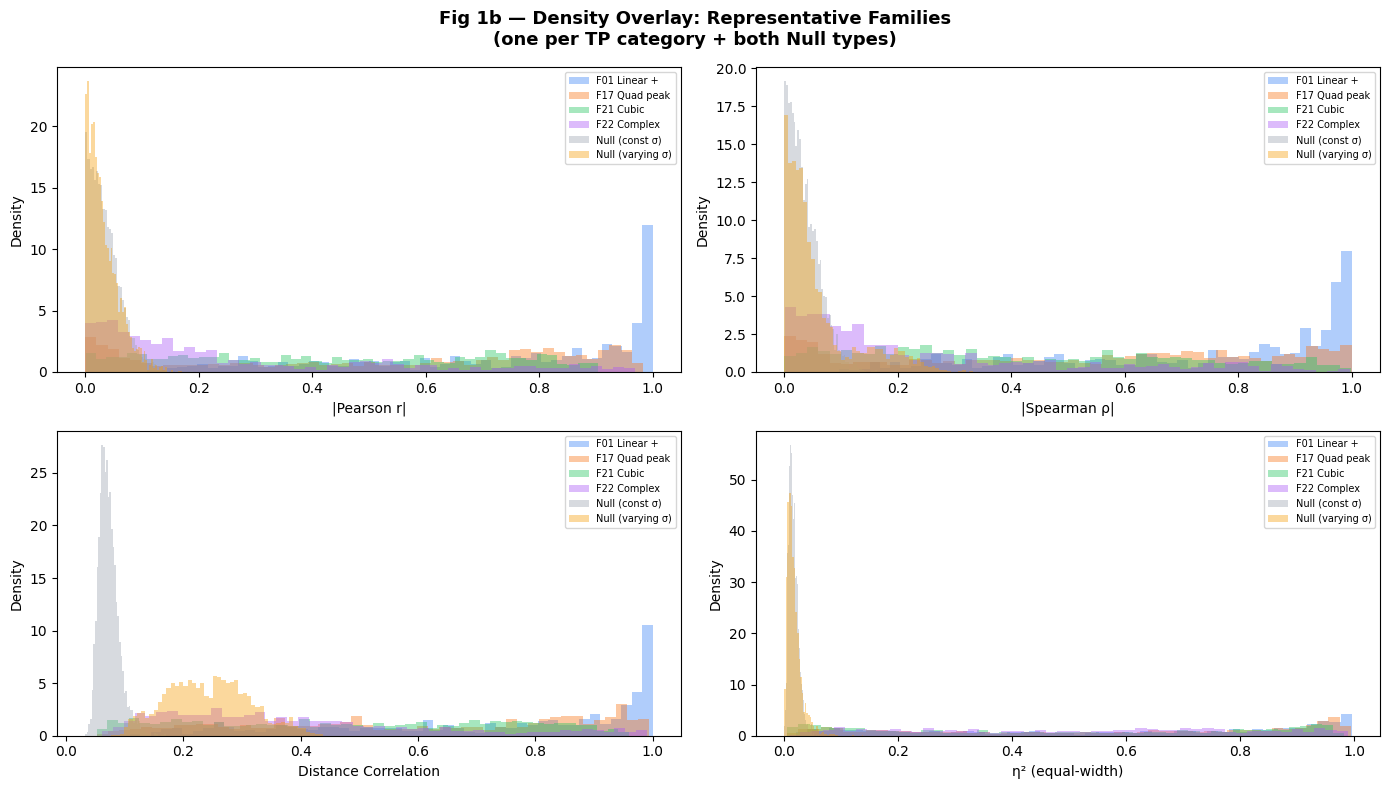

,|Pearson r|,|Spearman ρ|,Distance Correlation,η² (equal-width)
F01 Linear +,0.8289,0.8277,0.8133,0.6716
F02 Linear −,0.8298,0.8308,0.8169,0.6808
F03 Power cvx +,0.7581,0.7470,0.7453,0.6194
F04 Power cvx −,0.7475,0.7455,0.7417,0.6102
F05 Power ccv +,0.7908,0.7839,0.7740,0.6216
F06 Power ccv −,0.7908,0.7870,0.7700,0.6205
F07 Saturation +,0.5512,0.5597,0.5711,0.4851
F08 Saturation −,0.5575,0.5718,0.5758,0.4733
F09 Log +,0.7874,0.7763,0.7668,0.6267
F10 Log −,0.7819,0.7827,0.7656,0.6267


In [3]:
# --- Prepare profile data ---
# Signal families: mean-only (constant spread) to isolate mean response
signal_prof = df[df['category'] == 'mean_only'].copy()
signal_prof['group'] = signal_prof['family_id']

# Null: separate constant vs varying
null_c = df[df['category'] == 'true_null'].copy()
null_c['group'] = 'Null (const σ)'
null_v = df[df['category'] == 'variance_only'].copy()
null_v['group'] = 'Null (varying σ)'

profile_df = pd.concat([signal_prof, null_c, null_v], ignore_index=True)
profile_df['group_label'] = profile_df['group'].map(FAMILY_SHORT)

# --- Fig 1: Family fingerprint boxplots (horizontal, 24 rows × 6 metrics) ---
fig, axes = plt.subplots(1, 6, figsize=(30, 14), sharey=True)

for ax, metric, label in zip(axes, CORE_METRICS, CORE_LABELS):
    if metric not in profile_df.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=profile_df, y='group_label', x=metric, ax=ax,
                order=FAMILY_GROUP_LABELS, hue='group_label',
                palette=FAMILY_GROUP_PALETTE,
                fliersize=0.3, linewidth=0.7, width=0.7, legend=False)
    # Null baseline reference line
    null_med = profile_df.loc[profile_df['group'] == 'Null (const σ)', metric].median()
    ax.axvline(null_med, color='#666666', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel(label, fontsize=11)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('')
    if ax == axes[0]:
        ax.tick_params(axis='y', labelsize=9)
        # Add horizontal separator lines between TP groups
        for sep_y in [15.5, 19.5, 20.5, 21.5]:
            ax.axhline(sep_y, color='grey', linewidth=0.4, linestyle=':', alpha=0.5)

plt.suptitle('Fig 1 — Function Family Metric Fingerprints\n'
             '(signal families: mean-only / constant spread / all SNR; '
             'dashed line = True Null baseline)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig1_family_fingerprints.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Fig 1b: Density overlay per metric — selected families ---
# Pick representatives: one per TP group + both null types
rep_groups = {
    'F01 Linear +': '#3b82f6',
    'F17 Quad peak': '#f97316',
    'F21 Cubic': '#22c55e',
    'F22 Complex': '#a855f7',
    'Null (const σ)': '#9ca3af',
    'Null (varying σ)': '#f59e0b',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in profile_df.columns:
        ax.set_visible(False)
        continue
    for glabel, color in rep_groups.items():
        vals = profile_df.loc[profile_df['group_label'] == glabel, metric].dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=50, alpha=0.4, color=color, density=True, label=glabel)
    ax.set_xlabel(label)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right')
plt.suptitle('Fig 1b — Density Overlay: Representative Families\n'
             '(one per TP category + both Null types)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig1b_family_densities.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Median summary table ---
fam_medians = profile_df.groupby('group')[[m for m in CORE_METRICS if m in profile_df.columns]].median()
fam_medians = fam_medians.loc[FAMILY_GROUP_ORDER].round(4)
fam_medians.index = FAMILY_GROUP_LABELS
fam_medians.columns = CORE_LABELS[:len(fam_medians.columns)]
display(fam_medians)

## 2. Null Baseline Deep Dive

Zoomed comparison of the two Null types:
- **True Null** (f=0, constant σ): the "no relationship" ground truth
- **Variance-only** (f=0, varying σ): real dependence through variance

Key question: which metric separates them, and which cannot?

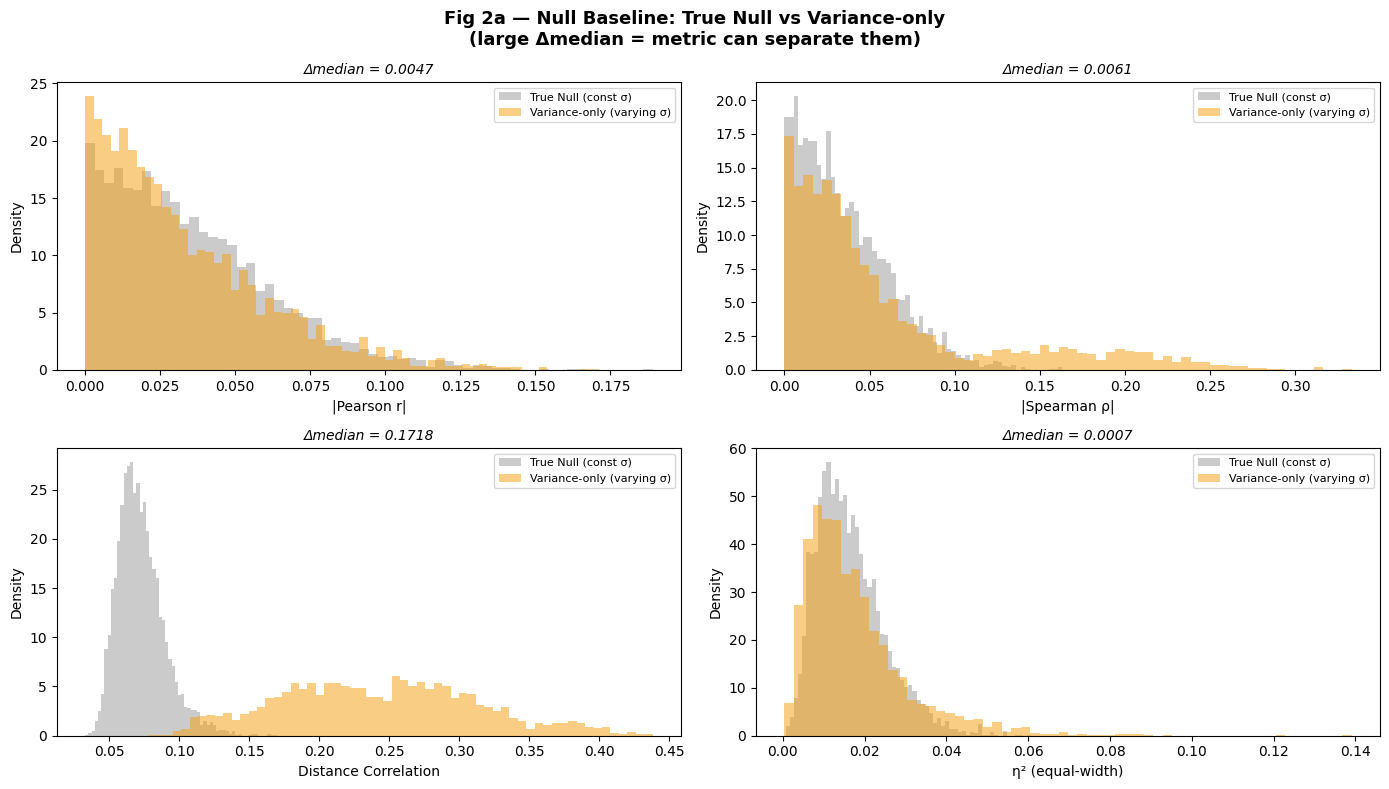

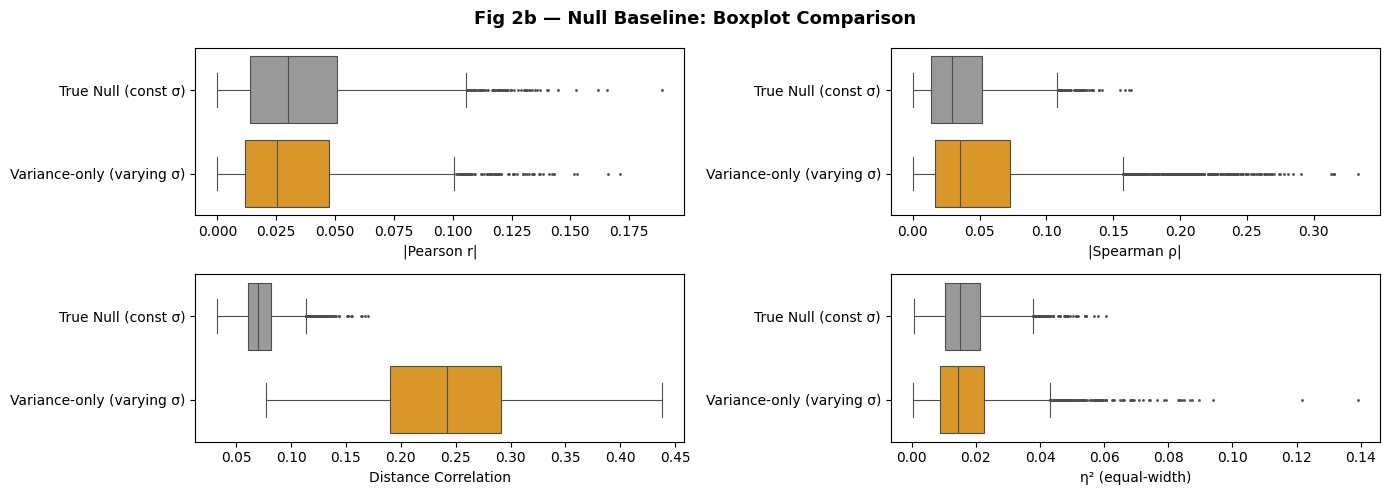

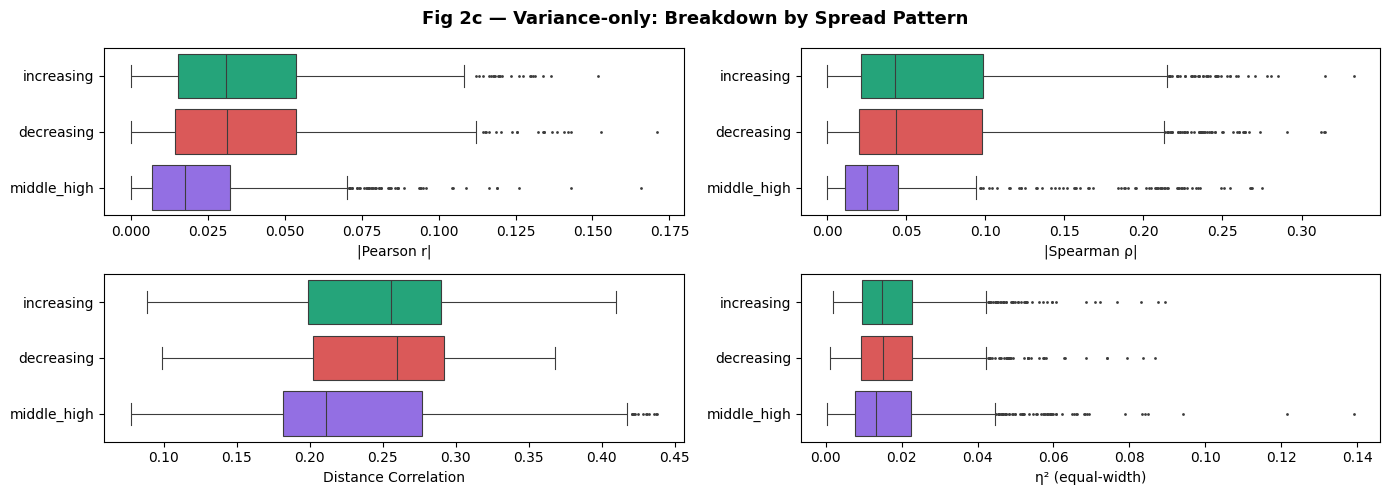

Median per null type:
  |Pearson r|                True Null=0.0302  Var-only=0.0255  ratio=0.8×
  |Spearman ρ|               True Null=0.0293  Var-only=0.0354  ratio=1.2×
  Distance Correlation       True Null=0.0702  Var-only=0.2421  ratio=3.4×
  η² (equal-width)           True Null=0.0151  Var-only=0.0144  ratio=1.0×


In [4]:
null_df = df[df['family_id'] == 'Null'].copy()
null_df['null_type'] = null_df['category'].map({
    'true_null': 'True Null (const σ)',
    'variance_only': 'Variance-only (varying σ)',
})
null_type_order = ['True Null (const σ)', 'Variance-only (varying σ)']
null_palette = {null_type_order[0]: CAT_COLORS['true_null'],
                null_type_order[1]: CAT_COLORS['variance_only']}

# --- Fig 2a: Density overlay — True Null vs Variance-only ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in null_df.columns:
        ax.set_visible(False)
        continue
    for nt, color in null_palette.items():
        vals = null_df.loc[null_df['null_type'] == nt, metric].dropna()
        ax.hist(vals, bins=60, alpha=0.5, color=color, density=True, label=nt)
    ax.set_xlabel(label)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

    # Annotate separation
    med_tn = null_df.loc[null_df['null_type'] == null_type_order[0], metric].median()
    med_vo = null_df.loc[null_df['null_type'] == null_type_order[1], metric].median()
    sep = abs(med_vo - med_tn)
    ax.set_title(f'Δmedian = {sep:.4f}', fontsize=10, style='italic')

plt.suptitle('Fig 2a — Null Baseline: True Null vs Variance-only\n'
             '(large Δmedian = metric can separate them)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2a_null_density.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Fig 2b: Horizontal boxplots — True Null vs Variance-only ---
fig, axes = plt.subplots(2, 3, figsize=(18, 6))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in null_df.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=null_df, y='null_type', x=metric, ax=ax,
                order=null_type_order, hue='null_type', palette=null_palette,
                fliersize=1, linewidth=0.8, legend=False)
    ax.set_xlabel(label)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('')
plt.suptitle('Fig 2b — Null Baseline: Boxplot Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2b_null_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Fig 2c: Variance-only breakdown by spread pattern ---
vo_df = null_df[null_df['category'] == 'variance_only'].copy()
spread_order = ['increasing', 'decreasing', 'middle_high']
spread_palette = {'increasing': '#10b981', 'decreasing': '#ef4444', 'middle_high': '#8b5cf6'}

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in vo_df.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=vo_df, y='spread_pattern', x=metric, ax=ax,
                order=spread_order, hue='spread_pattern', palette=spread_palette,
                fliersize=1, linewidth=0.8, legend=False)
    ax.set_xlabel(label)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('')
plt.suptitle('Fig 2c — Variance-only: Breakdown by Spread Pattern',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2c_variance_only_spread.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary: which metric separates Null types? ---
print('Median per null type:')
for m, l in zip(CORE_METRICS, CORE_LABELS):
    if m in null_df.columns:
        tn = null_df.loc[null_df['category'] == 'true_null', m].median()
        vo = null_df.loc[null_df['category'] == 'variance_only', m].median()
        ratio = vo / tn if tn > 1e-10 else float('inf')
        print(f'  {l:25s}  True Null={tn:.4f}  Var-only={vo:.4f}  ratio={ratio:.1f}×')

## 3. Category Overview

How do the 4 relationship categories separate on each metric?
Violin plots show both the distribution shape and density.

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_33678/2034127595.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([CAT_LABELS[c] for c in CAT_ORDER])
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_33678/2034127595.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([CAT_LABELS[c] for c in CAT_ORDER])
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_33678/2034127595.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([CAT_LABELS[c] for c in CAT_ORDER])
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_33678/2034127595.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

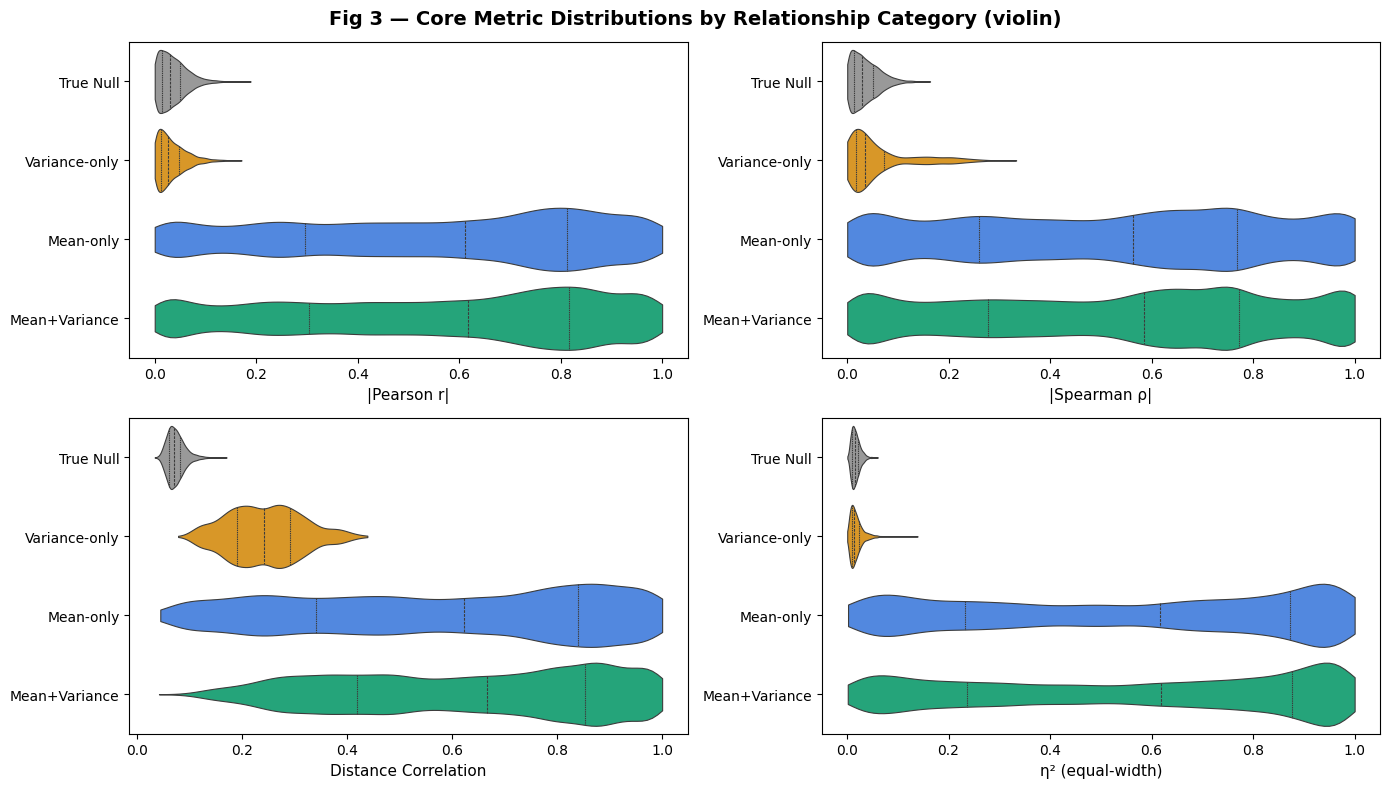

pearson_r         spearman_rho         distance_correlation  \
                 median     std       median     std               median   
category                                                                    
true_null        0.0302  0.0268       0.0293  0.0268               0.0702   
variance_only    0.0255  0.0275       0.0354  0.0633               0.2421   
mean_only        0.6109  0.2971       0.5627  0.3021               0.6225   
mean+variance    0.6171  0.2979       0.5853  0.3016               0.6661   

                      ew_bin_eta_squared          
                  std             median     std  
category                                          
true_null      0.0171             0.0151  0.0084  
variance_only  0.0702             0.0144  0.0130  
mean_only      0.2802             0.6160  0.3296  
mean+variance  0.2456             0.6187  0.3293

In [5]:
# --- Fig 3: Category violin plots (horizontal) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in df.columns:
        ax.set_visible(False)
        continue
    sns.violinplot(data=df, y='category', x=metric, ax=ax,
                   order=CAT_ORDER, hue='category', palette=CAT_COLORS,
                   inner='quartile', linewidth=0.8, cut=0, density_norm='width',
                   legend=False)
    ax.set_yticklabels([CAT_LABELS[c] for c in CAT_ORDER])
    ax.set_xlabel(label, fontsize=11)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('')
plt.suptitle('Fig 3 — Core Metric Distributions by Relationship Category (violin)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig3_category_violins.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Category summary table ---
available_core = [m for m in CORE_METRICS if m in df.columns]
cat_summary = df.groupby('category')[available_core].agg(['median', 'std']).round(4)
cat_summary = cat_summary.loc[CAT_ORDER]
display(cat_summary)

## 4. Core Metrics vs SNR

Mean-only cases (constant spread): how metric values rise with signal strength.

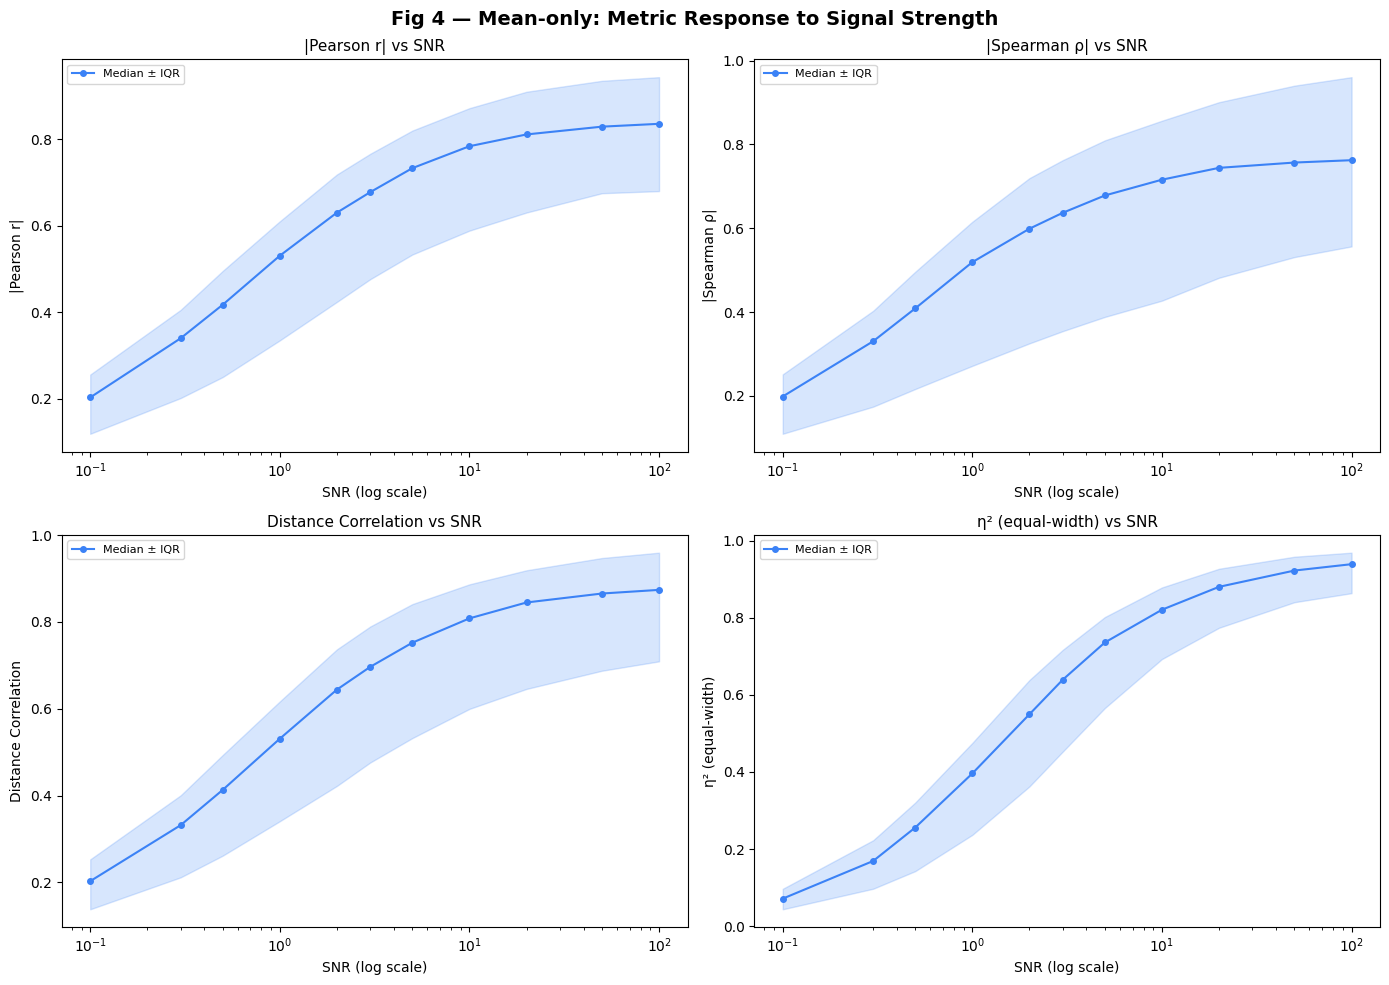

In [6]:
mean_only_snr = df[df['category'] == 'mean_only'].copy()
mean_only_snr['snr_num'] = pd.to_numeric(mean_only_snr['snr'], errors='coerce')
mean_only_snr = mean_only_snr[mean_only_snr['snr_num'].notna() & np.isfinite(mean_only_snr['snr_num'])]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in mean_only_snr.columns:
        ax.set_title(f'{label} (not available)')
        continue
    grouped = mean_only_snr.groupby('snr_num')[metric].agg(
        ['median', 'mean',
         lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    grouped.columns = ['snr', 'median', 'mean', 'q25', 'q75']
    ax.fill_between(grouped['snr'], grouped['q25'], grouped['q75'],
                    alpha=0.2, color='#3b82f6')
    ax.plot(grouped['snr'], grouped['median'], 'o-', color='#3b82f6',
            markersize=4, label='Median ± IQR')
    ax.set_xscale('log')
    ax.set_xlabel('SNR (log scale)')
    ax.set_ylabel(label)
    apply_metric_axis(ax, metric, axis='y')
    ax.set_title(f'{label} vs SNR', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Fig 4 — Mean-only: Metric Response to Signal Strength',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig4_snr_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Metric Correlation Matrix

Pairwise Pearson correlation of all numeric metrics. Identifies redundant vs. complementary metrics.

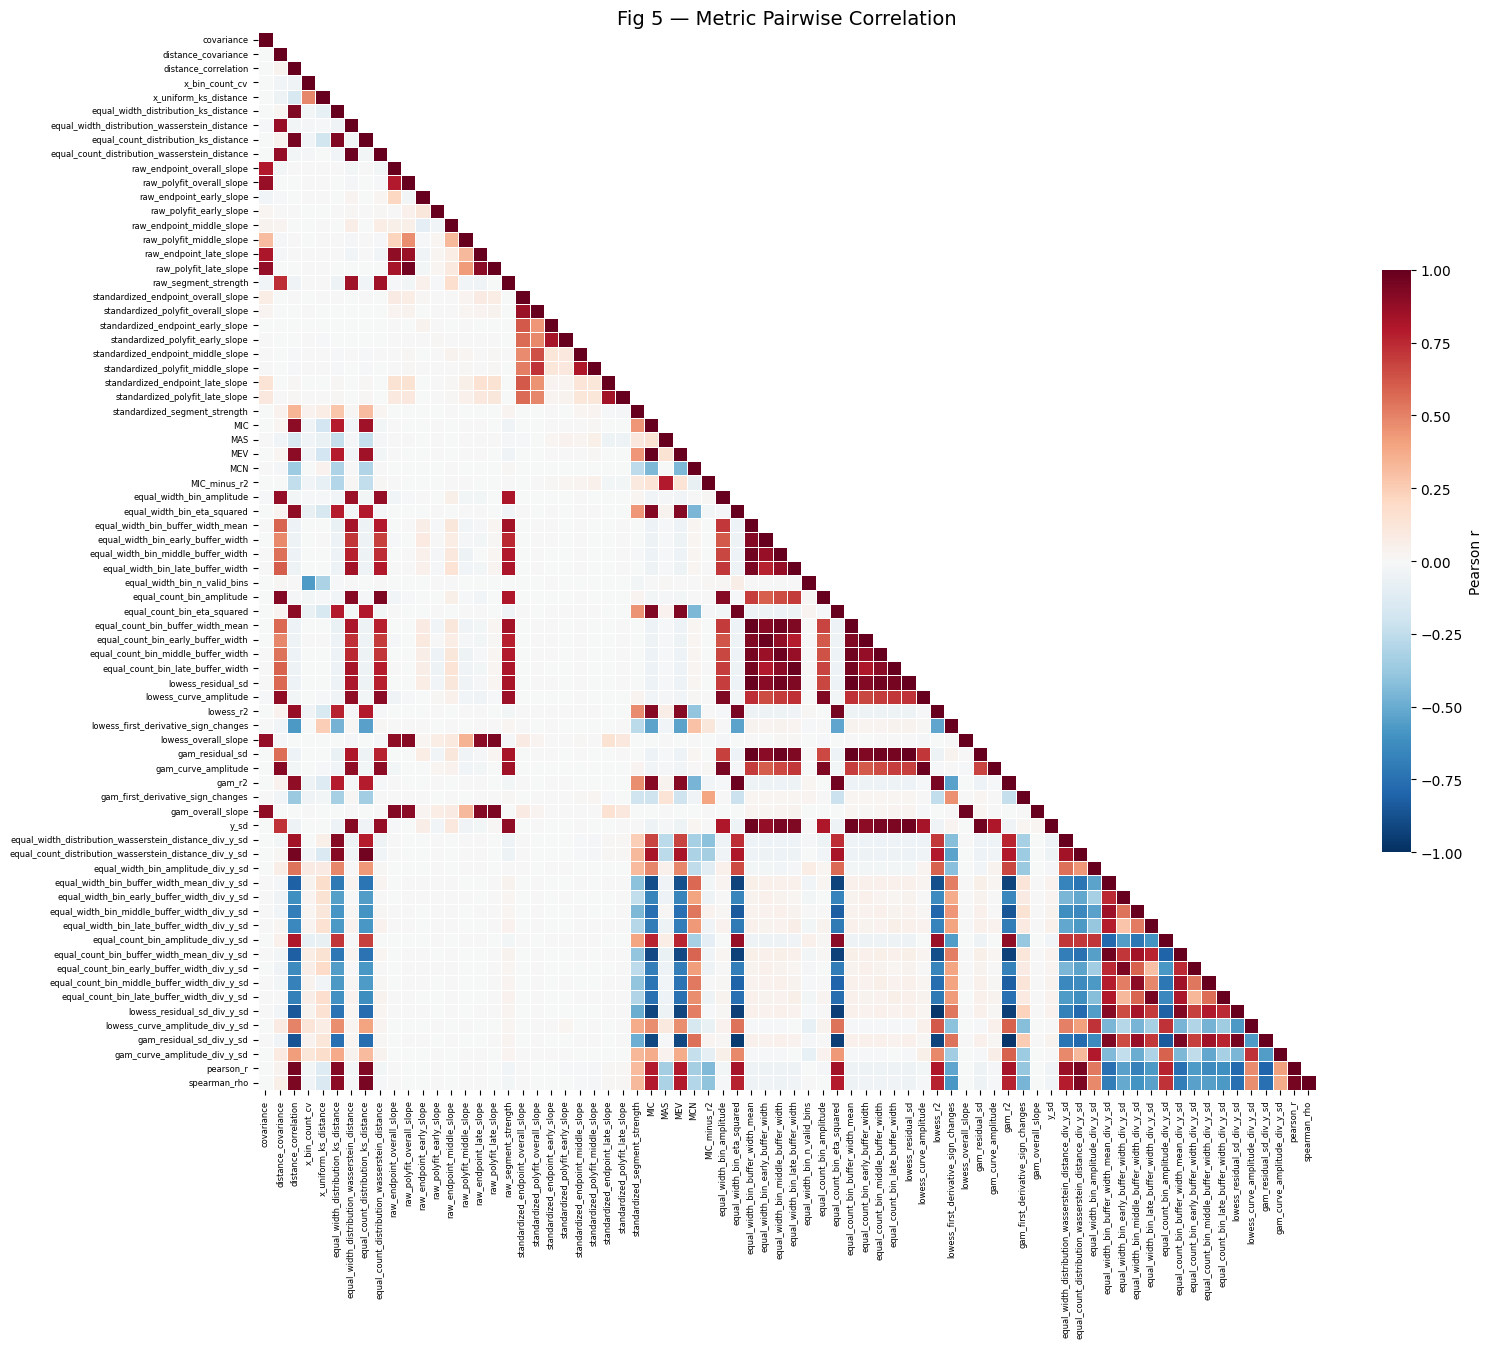

Selected 6 metrics — pairwise correlation:


,|Pearson r|,|Spearman ρ|,Distance Correlation,η² (equal-width)
|Pearson r|,1.000,0.961,0.961,0.834
|Spearman ρ|,0.961,1.000,0.943,0.772
Distance Correlation,0.961,0.943,1.000,0.890
η² (equal-width),0.834,0.772,0.890,1.000


In [7]:
metric_cols = [c for c in metrics.columns if c not in ('case_id', 'source', 'n_valid')
               and df[c].dtype in ('float64', 'float32', 'int64')]
metric_cols = [c for c in metric_cols if df[c].std() > 1e-10]

corr = df[metric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.5, 'label': 'Pearson r'})
ax.set_title('Fig 5 — Metric Pairwise Correlation', fontsize=14)
ax.tick_params(labelsize=6)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig5_metric_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Selected 6 metrics: pairwise correlation
core_avail = [m for m in CORE_METRICS if m in df.columns]
core_corr = df[core_avail].corr().round(3)
core_corr.index = [l for m, l in zip(CORE_METRICS, CORE_LABELS) if m in df.columns]
core_corr.columns = core_corr.index
print('Selected 6 metrics — pairwise correlation:')
display(core_corr)

## 6. Spread Pattern Effect

For a fixed function family (F01 Linear, SNR=2.0, even x), how do the 4 spread
patterns shift metric distributions?

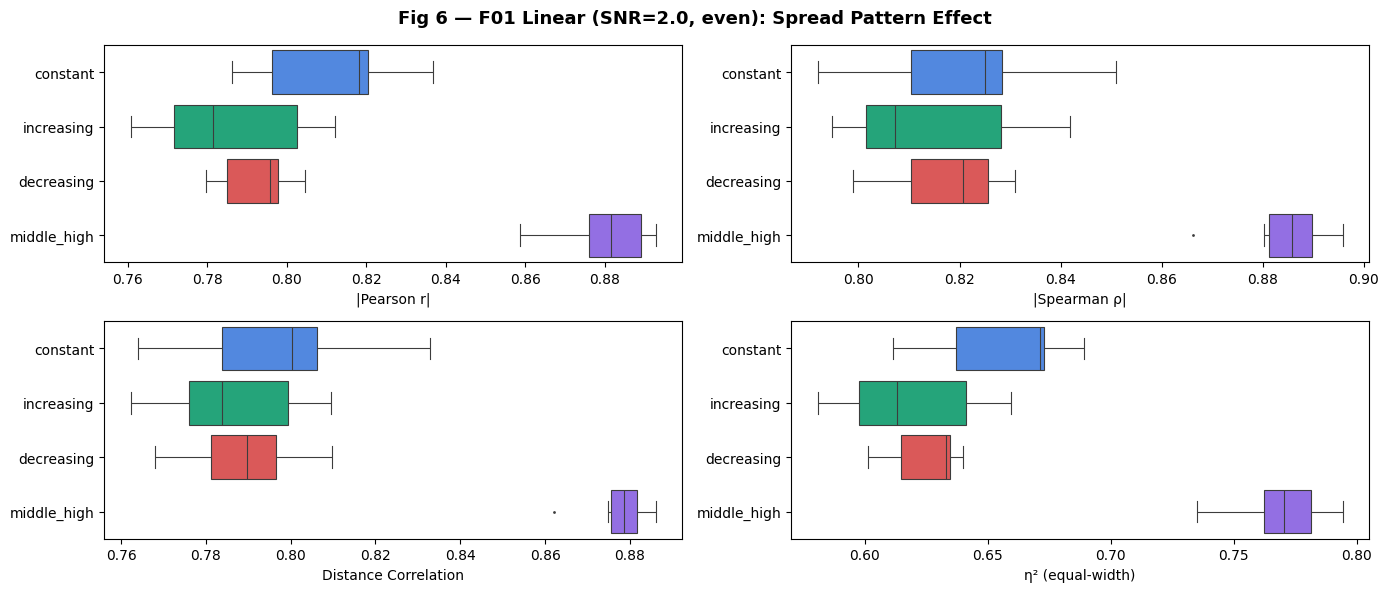

In [8]:
f01 = df[(df['family_id'] == 'F01') & (df['snr'] == 2.0) &
         (df['x_distribution'] == 'even')].copy()

spread_order = ['constant', 'increasing', 'decreasing', 'middle_high']
spread_colors = {'constant': '#3b82f6', 'increasing': '#10b981',
                 'decreasing': '#ef4444', 'middle_high': '#8b5cf6'}

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in f01.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=f01, y='spread_pattern', x=metric, ax=ax,
                order=spread_order, hue='spread_pattern', palette=spread_colors,
                fliersize=1, linewidth=0.8, legend=False)
    ax.set_xlabel(label)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('')
plt.suptitle('Fig 6 — F01 Linear (SNR=2.0, even): Spread Pattern Effect',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig6_spread_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. X-Distribution Influence

Does the sampling density of x bias metric values?
Mean-only cases at SNR=2.0, grouped by x_distribution.

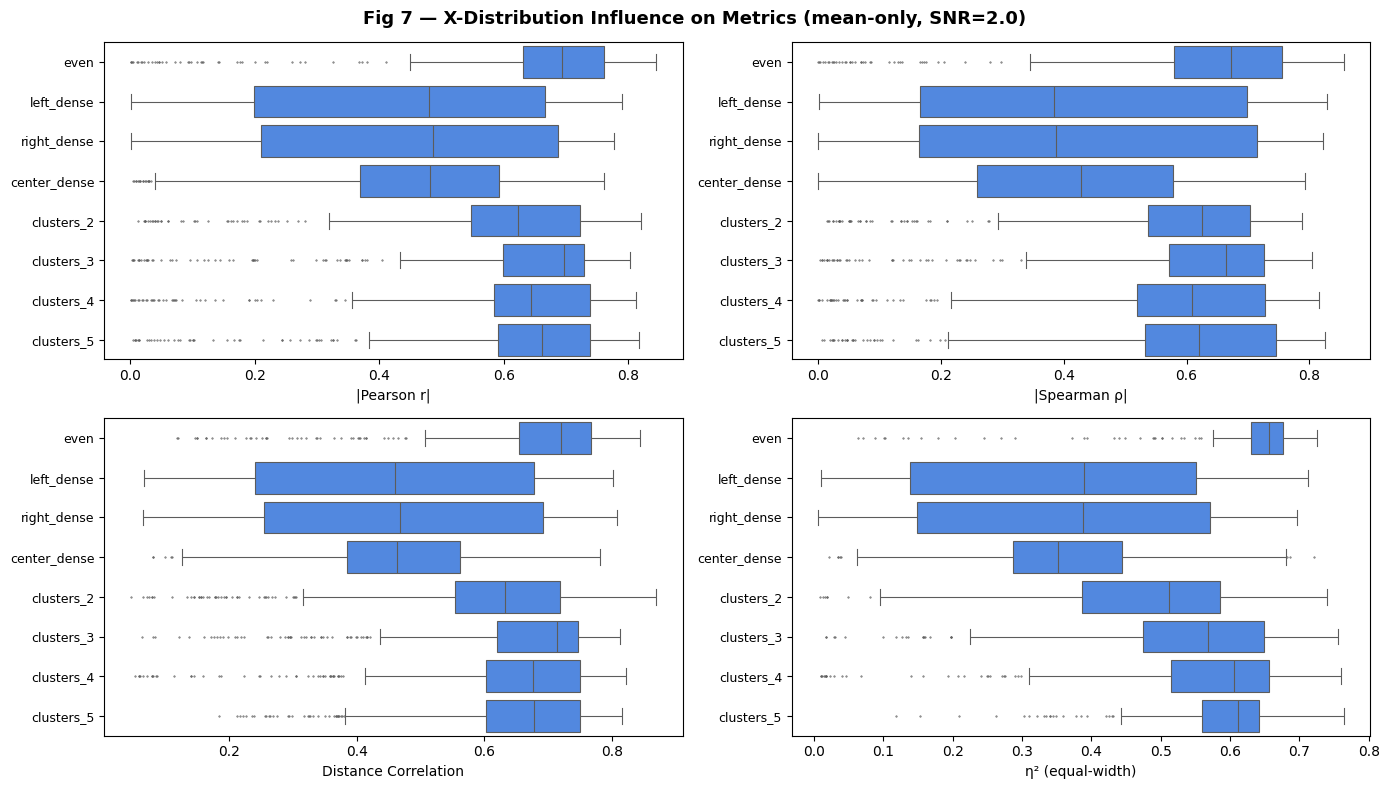

In [9]:
xdist_sub = df[(df['category'] == 'mean_only') & (df['snr'] == 2.0)].copy()
x_dist_order = ['even', 'left_dense', 'right_dense', 'center_dense',
                'clusters_2', 'clusters_3', 'clusters_4', 'clusters_5']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, metric, label in zip(axes.flat, CORE_METRICS, CORE_LABELS):
    if metric not in xdist_sub.columns:
        ax.set_visible(False)
        continue
    sns.boxplot(data=xdist_sub, y='x_distribution', x=metric, ax=ax,
                order=x_dist_order, color='#3b82f6',
                fliersize=0.5, linewidth=0.8)
    ax.set_xlabel(label)
    apply_metric_axis(ax, metric)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=9)
plt.suptitle('Fig 7 — X-Distribution Influence on Metrics (mean-only, SNR=2.0)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig7_xdist_influence.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. All-Metric Exploratory Screening

This section includes all numeric metrics from `metrics_full.parquet`. It is exploratory only. The goal is to screen which observed metrics separate known relationship categories before formal permutation testing.

In [ ]:
ALL_METRIC_COLS = [
    c for c in metrics.columns
    if c not in ('case_id', 'source', 'n_valid')
    and c in df.columns
    and pd.api.types.is_numeric_dtype(df[c])
    and df[c].notna().sum() > 0
    and df[c].std(skipna=True) > 1e-12
]

print(f'All numeric metrics included: {len(ALL_METRIC_COLS)}')

def robust_iqr(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    iqr = x.quantile(0.75) - x.quantile(0.25)
    if iqr < 1e-12:
        iqr = x.std() * 1.35
    return float(iqr) if iqr >= 1e-12 else np.nan

rows = []
for metric in ALL_METRIC_COLS:
    vals = {cat: df.loc[df['category'] == cat, metric].dropna() for cat in CAT_ORDER}
    med = {cat: float(vals[cat].median()) if len(vals[cat]) else np.nan for cat in CAT_ORDER}
    scale = robust_iqr(vals['true_null'])
    if not np.isfinite(scale) or scale < 1e-12:
        scale = robust_iqr(df[metric])
    if not np.isfinite(scale) or scale < 1e-12:
        continue

    row = {
        'metric': metric,
        'true_null_median': med['true_null'],
        'variance_only_median': med['variance_only'],
        'mean_only_median': med['mean_only'],
        'mean_variance_median': med['mean+variance'],
        'true_null_iqr': scale,
        'sep_variance_only_vs_true_null': abs(med['variance_only'] - med['true_null']) / scale,
        'sep_mean_only_vs_true_null': abs(med['mean_only'] - med['true_null']) / scale,
        'sep_mean_variance_vs_true_null': abs(med['mean+variance'] - med['true_null']) / scale,
        'direction_variance_only': 'higher' if med['variance_only'] > med['true_null'] else 'lower',
    }
    rows.append(row)

all_metric_screen = pd.DataFrame(rows)
all_metric_screen['max_category_separation'] = all_metric_screen[
    ['sep_variance_only_vs_true_null', 'sep_mean_only_vs_true_null', 'sep_mean_variance_vs_true_null']
].max(axis=1)
all_metric_screen = all_metric_screen.sort_values('max_category_separation', ascending=False)

out_csv = S2_DIR / 'all_metric_observed_screening.csv'
all_metric_screen.to_csv(out_csv, index=False)
print(f'Saved screening table: {out_csv}')

print('\nTop metrics separating Variance-only from True Null:')
display(all_metric_screen.sort_values('sep_variance_only_vs_true_null', ascending=False).head(25))

print('\nTop metrics separating Mean-only from True Null:')
display(all_metric_screen.sort_values('sep_mean_only_vs_true_null', ascending=False).head(25))

In [ ]:
# Robust category-median heatmap for all metrics.
# Values are centered and scaled using the True Null distribution of each metric.
heat_rows = []
for _, row in all_metric_screen.iterrows():
    metric = row['metric']
    base = row['true_null_median']
    scale = row['true_null_iqr']
    heat_rows.append({
        'metric': metric,
        'True Null': 0.0,
        'Variance-only': (row['variance_only_median'] - base) / scale,
        'Mean-only': (row['mean_only_median'] - base) / scale,
        'Mean+Variance': (row['mean_variance_median'] - base) / scale,
    })

heat_df = pd.DataFrame(heat_rows).set_index('metric')
heat_df = heat_df.loc[all_metric_screen.sort_values('max_category_separation', ascending=False)['metric']]

fig_h = max(12, 0.24 * len(heat_df))
fig, ax = plt.subplots(figsize=(9, fig_h))
sns.heatmap(heat_df.clip(-10, 10), cmap='RdBu_r', center=0,
            vmin=-10, vmax=10, linewidths=0.2, linecolor='white',
            cbar_kws={'label': 'Median shift from True Null, scaled by True Null IQR'}, ax=ax)
ax.set_title('Fig 8 — All Metrics: Category-Median Shift Relative to True Null\n(clipped to ±10 IQR for readability)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Relationship category')
ax.set_ylabel('Metric')
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig8_all_metric_category_shift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Density plots for the metrics that most separate Variance-only from True Null.
top_vo_metrics = all_metric_screen.sort_values('sep_variance_only_vs_true_null', ascending=False)['metric'].head(24).tolist()

fig, axes = plt.subplots(4, 6, figsize=(24, 13))
for ax, metric in zip(axes.flat, top_vo_metrics):
    tn_vals = df.loc[df['category'] == 'true_null', metric].dropna()
    vo_vals = df.loc[df['category'] == 'variance_only', metric].dropna()
    ax.hist(tn_vals, bins=50, alpha=0.5, color=CAT_COLORS['true_null'], density=True, label='True Null')
    ax.hist(vo_vals, bins=50, alpha=0.5, color=CAT_COLORS['variance_only'], density=True, label='Variance-only')
    sep = all_metric_screen.loc[all_metric_screen['metric'] == metric, 'sep_variance_only_vs_true_null'].iloc[0]
    ax.set_title(f'{metric}\nsep={sep:.2f} IQR', fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes.flat[len(top_vo_metrics):]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)
plt.suptitle('Fig 9 — Top Observed Metrics Separating Variance-only from True Null',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.98, 0.96])
fig.savefig(VIZ_DIR / 'fig9_top_variance_only_metric_densities.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. True Null Baseline Range Analysis

This section strengthens the observed-metric screening by using the True Null cases as an empirical no-relationship baseline. For each metric, we compare relationship-category distributions against the True Null range. This is still descriptive screening, not a formal hypothesis test.


In [ ]:
# Core-metric density overlays with the True Null 95% upper baseline.
# This visualizes whether relationship categories move beyond the observed True Null range.

CORE_AVAILABLE = [m for m in CORE_METRICS if m in df.columns]
CORE_LABEL_MAP = {m: l for m, l in zip(CORE_METRICS, CORE_LABELS)}

# For these selected metrics, larger values indicate stronger apparent relationship.
HIGHER_IS_RELATIONSHIP = set(CORE_AVAILABLE)

core_range_rows = []
for metric in CORE_AVAILABLE:
    tn_vals = df.loc[df['category'] == 'true_null', metric].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tn_vals) == 0:
        continue
    q025 = float(tn_vals.quantile(0.025))
    q95 = float(tn_vals.quantile(0.95))
    q975 = float(tn_vals.quantile(0.975))
    tn_iqr = float(tn_vals.quantile(0.75) - tn_vals.quantile(0.25))
    if tn_iqr < 1e-12:
        tn_iqr = float(tn_vals.std() * 1.35)

    for cat in CAT_ORDER:
        vals = df.loc[df['category'] == cat, metric].replace([np.inf, -np.inf], np.nan).dropna()
        core_range_rows.append({
            'metric': metric,
            'metric_label': CORE_LABEL_MAP[metric],
            'category': cat,
            'n': len(vals),
            'median': float(vals.median()) if len(vals) else np.nan,
            'q025': float(vals.quantile(0.025)) if len(vals) else np.nan,
            'q975': float(vals.quantile(0.975)) if len(vals) else np.nan,
            'true_null_q95': q95,
            'true_null_q025': q025,
            'true_null_q975': q975,
            'true_null_iqr': tn_iqr,
            'median_shift_vs_true_null_iqr': (
                abs(float(vals.median()) - float(tn_vals.median())) / tn_iqr
                if len(vals) and tn_iqr > 1e-12 else np.nan
            ),
            'exceed_true_null_q95': float((vals > q95).mean()) if len(vals) else np.nan,
            'central_95_width': float(vals.quantile(0.975) - vals.quantile(0.025)) if len(vals) else np.nan,
            'overlaps_true_null_95': bool(
                (float(vals.quantile(0.025)) <= q975) and (float(vals.quantile(0.975)) >= q025)
            ) if len(vals) else np.nan,
        })

core_range_summary = pd.DataFrame(core_range_rows)
display(core_range_summary.pivot(index='metric_label', columns='category', values='exceed_true_null_q95').loc[[CORE_LABEL_MAP[m] for m in CORE_AVAILABLE]].round(3))

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flat
for ax, metric in zip(axes, CORE_AVAILABLE):
    label = CORE_LABEL_MAP[metric]
    tn_vals = df.loc[df['category'] == 'true_null', metric].replace([np.inf, -np.inf], np.nan).dropna()
    q95 = float(tn_vals.quantile(0.95))

    for cat in CAT_ORDER:
        vals = df.loc[df['category'] == cat, metric].replace([np.inf, -np.inf], np.nan).dropna()
        if len(vals) == 0:
            continue
        ax.hist(vals, bins=60, density=True, alpha=0.35,
                color=CAT_COLORS[cat], label=CAT_LABELS[cat])

    ax.axvline(q95, color='black', ls='--', lw=1.6, label='True Null 95th percentile')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Observed metric value')
    ax.set_ylabel('Density')
    apply_metric_axis(ax, metric)
    ax.legend(fontsize=7)

for ax in axes[len(CORE_AVAILABLE):]:
    ax.set_visible(False)

plt.suptitle('Fig 10 — Observed Metric Distributions vs True Null Baseline Range',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig10_core_metrics_true_null_baseline_density.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# Exceedance-rate heatmap: fraction of cases above the True Null 95th percentile.
# High values indicate that the metric often moves beyond the no-relationship baseline for that category.

exceed_heat = core_range_summary.pivot(index='metric_label', columns='category', values='exceed_true_null_q95')
exceed_heat = exceed_heat.loc[[CORE_LABEL_MAP[m] for m in CORE_AVAILABLE], CAT_ORDER]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(exceed_heat, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Fraction above True Null 95th percentile'}, ax=ax)
ax.set_title('Fig 11 — Exceedance Above True Null Baseline by Metric and Category',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Relationship category')
ax.set_ylabel('Metric')
ax.set_xticklabels([CAT_LABELS[c] for c in CAT_ORDER], rotation=25, ha='right')
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig11_core_metric_true_null_exceedance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: values near 0.05 for True Null are expected by construction. Higher values for relationship categories indicate stronger observed separation from the no-relationship baseline.')



In [ ]:
# Objective Fig 12: metric response based on the empirical 95% True Null range.
# For each metric, first estimate its central 95% range under True Null:
#     [q2.5_null, q97.5_null]
# Then compute the fraction of cases in each category falling outside that range.
# This gives a scale-free, direction-free response score for every metric.

candidate_metric_cols = list(metrics.columns)
for alias_col in ['ew_bin_eta_squared', 'ec_bin_eta_squared']:
    if alias_col in df.columns and alias_col not in candidate_metric_cols:
        candidate_metric_cols.append(alias_col)

if 'ALL_METRIC_COLS' not in globals():
    ALL_METRIC_COLS = [
        c for c in candidate_metric_cols
        if c not in ('case_id', 'source', 'n_valid')
        and c in df.columns
        and pd.api.types.is_numeric_dtype(df[c])
        and df[c].notna().sum() > 0
        and df[c].std(skipna=True) > 1e-12
    ]
else:
    for alias_col in ['ew_bin_eta_squared', 'ec_bin_eta_squared']:
        if alias_col in df.columns and alias_col not in ALL_METRIC_COLS:
            ALL_METRIC_COLS.append(alias_col)

CORE_LABEL_MAP = {m: l for m, l in zip(CORE_METRICS, CORE_LABELS)}
PRETTY_LABELS = {
    'MIC_minus_r2': 'MIC - R²',
    'equal_width_bin_eta_squared': 'η², equal-width bins',
    'equal_count_bin_eta_squared': 'η², equal-count bins',
    'ew_bin_eta_squared': 'η², equal-width bins',
    'ec_bin_eta_squared': 'η², equal-count bins',
    'equal_count_distribution_ks_distance': 'Distribution KS, equal-count',
    'equal_width_distribution_ks_distance': 'Distribution KS, equal-width',
    'equal_count_distribution_wasserstein_distance_div_y_sd': 'Distribution Wasserstein / y SD, equal-count',
    'equal_width_distribution_wasserstein_distance_div_y_sd': 'Distribution Wasserstein / y SD, equal-width',
    'gam_r2': 'GAM R²',
    'lowess_r2': 'LOWESS R²',
}

def pretty_metric_name(metric):
    if metric in CORE_LABEL_MAP:
        return CORE_LABEL_MAP[metric]
    if metric in PRETTY_LABELS:
        return PRETTY_LABELS[metric]
    return metric.replace('_', ' ')

outside_rows = []
for metric in ALL_METRIC_COLS:
    vals_all = df[metric].replace([np.inf, -np.inf], np.nan).dropna()
    tn_vals = df.loc[df['category'] == 'true_null', metric].replace([np.inf, -np.inf], np.nan).dropna()
    if len(vals_all) == 0 or len(tn_vals) == 0 or vals_all.std() <= 1e-12:
        continue

    q025 = float(tn_vals.quantile(0.025))
    q975 = float(tn_vals.quantile(0.975))
    if not np.isfinite(q025) or not np.isfinite(q975) or abs(q975 - q025) < 1e-12:
        continue

    row = {
        'metric': metric,
        'display_name': pretty_metric_name(metric),
        'true_null_q025': q025,
        'true_null_q975': q975,
        'true_null_95_width': q975 - q025,
    }
    for cat in CAT_ORDER:
        vals = df.loc[df['category'] == cat, metric].replace([np.inf, -np.inf], np.nan).dropna()
        row[f'{cat}_outside_rate'] = float(((vals < q025) | (vals > q975)).mean()) if len(vals) else np.nan
        row[f'{cat}_median'] = float(vals.median()) if len(vals) else np.nan

    row['max_relationship_outside_rate'] = np.nanmax([
        row['variance_only_outside_rate'],
        row['mean_only_outside_rate'],
        row['mean+variance_outside_rate'],
    ])
    row['mean_relationship_outside_rate'] = np.nanmean([
        row['variance_only_outside_rate'],
        row['mean_only_outside_rate'],
        row['mean+variance_outside_rate'],
    ])
    outside_rows.append(row)

all_metric_null_range = pd.DataFrame(outside_rows).sort_values(
    ['max_relationship_outside_rate', 'mean_relationship_outside_rate'], ascending=False
)

out_path = S2_DIR / 'all_metric_true_null_95range_outside_rate.csv'
all_metric_null_range.to_csv(out_path, index=False)
print(f'Saved full 95%-range outside-rate table: {out_path}')

print('\nTop metrics ranked by max relationship outside-rate:')
display(all_metric_null_range.head(25).round(3))

# Fig 12a: pre-specified core metrics only.
core_available = [m for m in CORE_METRICS if m in all_metric_null_range['metric'].values]
core_plot = all_metric_null_range.set_index('metric').loc[core_available].copy()
core_heat = core_plot[[f'{c}_outside_rate' for c in CAT_ORDER]]
core_heat.columns = [CAT_LABELS[c] for c in CAT_ORDER]
core_heat.index = [pretty_metric_name(m) for m in core_heat.index]

fig, ax = plt.subplots(figsize=(8.8, 4.8))
sns.heatmap(
    core_heat,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Fraction outside True Null 95% range'},
    ax=ax,
)
ax.set_title('Fig 12a — Core Metrics Outside the True Null 95% Range',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Data-generating category')
ax.set_ylabel('Pre-specified core metric')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
fig.text(
    0.5, 0.01,
    'Each cell = fraction of cases outside the empirical central 95% range of True Null. True Null should be about 0.05.',
    ha='center', va='bottom', fontsize=9, color='#444444'
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(VIZ_DIR / 'fig12a_core_metrics_true_null_95range_outside_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Fig 12b: balanced all-metric selection.
# Include metrics that separate True Null from all three relationship categories, not merely one.
# This answers: which metrics can consistently separate no relationship from the full set of relationship patterns?
FIG12B_MIN_EACH_RELATIONSHIP_RESPONSE = 0.70
FIG12B_MAX_TRUE_NULL_RATE = 0.10
REL_OUTSIDE_COLS = [
    'variance_only_outside_rate',
    'mean_only_outside_rate',
    'mean+variance_outside_rate',
]
selected = all_metric_null_range[
    (all_metric_null_range[REL_OUTSIDE_COLS].min(axis=1) >= FIG12B_MIN_EACH_RELATIONSHIP_RESPONSE)
    & (all_metric_null_range['true_null_outside_rate'] <= FIG12B_MAX_TRUE_NULL_RATE)
].copy()
selected['min_relationship_outside_rate'] = selected[REL_OUTSIDE_COLS].min(axis=1)
selected = selected.sort_values(
    ['mean_relationship_outside_rate', 'min_relationship_outside_rate', 'max_relationship_outside_rate'],
    ascending=False
)

selected_path = S2_DIR / 'fig12b_selected_metrics_true_null_95range_outside_rate.csv'
selected.to_csv(selected_path, index=False)
print(
    f'Fig 12b selected {len(selected)} balanced metrics using every relationship outside-rate >= '
    f'{FIG12B_MIN_EACH_RELATIONSHIP_RESPONSE} and True Null outside-rate <= {FIG12B_MAX_TRUE_NULL_RATE}.'
)
print(f'Saved Fig 12b selected metrics: {selected_path}')

def truncate_label(s, max_len=58):
    return s if len(s) <= max_len else s[:max_len - 3] + '...'

if len(selected) == 0:
    print('No metrics met the Fig 12b selection rule. Lower FIG12B_MIN_EACH_RELATIONSHIP_RESPONSE if needed.')
else:
    # Merge visually redundant variants for Fig 12b.
    # Raw selected metrics are preserved in selected_path; this grouped view uses the best representative
    # within each metric family based on mean relationship outside-rate.
    def fig12b_metric_group(metric, display_name):
        if metric == 'distance_correlation':
            return 'Distance Correlation'
        if metric == 'distance_covariance':
            return 'Distance covariance'
        if metric == 'MIC':
            return 'MIC'
        if metric == 'MEV':
            return 'MEV'
        if metric == 'MIC_minus_r2':
            return 'MIC - R²'
        if 'distribution_ks_distance' in metric:
            return 'Distribution KS'
        if 'distribution_wasserstein_distance_div_y_sd' in metric:
            return 'Distribution Wasserstein / y SD'
        if 'distribution_wasserstein_distance' in metric:
            return 'Distribution Wasserstein'
        if 'buffer_width' in metric and metric.endswith('_div_y_sd'):
            return 'Bin buffer width / y SD'
        if 'buffer_width' in metric:
            return 'Bin buffer width'
        if 'bin_amplitude' in metric and metric.endswith('_div_y_sd'):
            return 'Bin amplitude / y SD'
        if 'eta_squared' in metric:
            return 'Binned η²'
        return display_name

    selected_grouped = selected.copy()
    selected_grouped['fig12b_group'] = [
        fig12b_metric_group(m, d)
        for m, d in zip(selected_grouped['metric'], selected_grouped['display_name'])
    ]
    selected_grouped = selected_grouped.sort_values(
        ['mean_relationship_outside_rate', 'min_relationship_outside_rate', 'max_relationship_outside_rate'],
        ascending=False
    )
    grouped_plot = selected_grouped.groupby('fig12b_group', as_index=False).head(1).copy()
    grouped_plot = grouped_plot.sort_values(
        ['mean_relationship_outside_rate', 'min_relationship_outside_rate', 'max_relationship_outside_rate'],
        ascending=False
    )
    grouped_plot['representative_metric'] = grouped_plot['metric']
    grouped_plot['display_name_raw'] = grouped_plot['display_name']
    grouped_path = S2_DIR / 'fig12b_grouped_selected_metrics_true_null_95range_outside_rate.csv'
    grouped_plot.to_csv(grouped_path, index=False)
    print(f'Grouped Fig 12b rows: {len(grouped_plot)} metric families from {len(selected)} raw selected metrics.')
    print(f'Saved grouped Fig 12b table: {grouped_path}')
    display(grouped_plot[[
        'fig12b_group', 'representative_metric',
        'variance_only_outside_rate', 'mean_only_outside_rate', 'mean+variance_outside_rate',
        'mean_relationship_outside_rate'
    ]].round(3))

    def truncate_label(s, max_len=58):
        return s if len(s) <= max_len else s[:max_len - 3] + '...'

    heat = grouped_plot.set_index('fig12b_group')[[f'{c}_outside_rate' for c in CAT_ORDER]]
    heat.columns = [CAT_LABELS[c] for c in CAT_ORDER]
    heat.index = [truncate_label(s) for s in heat.index]

    fig, ax = plt.subplots(figsize=(9.5, max(5.5, 0.46 * len(heat) + 1.8)))
    sns.heatmap(
        heat,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        vmin=0,
        vmax=1,
        linewidths=0.45,
        cbar_kws={'label': 'Fraction outside True Null 95% range'},
        ax=ax,
    )
    ax.set_title('Fig 12b — Grouped Balanced Metrics Outside the True Null 95% Range',
                 fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel('Data-generating category')
    ax.set_ylabel('Metric family selected by outside-rate rule')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.tick_params(axis='y', labelsize=9)
    fig.text(
        0.5, 0.01,
        f'Raw metrics are first filtered by all three relationship outside-rates ≥ {FIG12B_MIN_EACH_RELATIONSHIP_RESPONSE:.2f} and True Null outside-rate ≤ {FIG12B_MAX_TRUE_NULL_RATE:.2f}; redundant equal-count/equal-width and early/late variants are merged by metric family.',
        ha='center', va='bottom', fontsize=8.5, color='#444444'
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(VIZ_DIR / 'fig12b_grouped_balanced_metrics_true_null_95range_outside_rate.png', dpi=150, bbox_inches='tight')
    # Keep the previous filename updated as the grouped main version for existing links.
    fig.savefig(VIZ_DIR / 'fig12b_selected_all_metrics_true_null_95range_outside_rate.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Presentation-friendly alias. Since the grouped figure is already short, this is the same content.
    fig, ax = plt.subplots(figsize=(9.5, max(5.5, 0.46 * len(heat) + 1.8)))
    sns.heatmap(
        heat,
        annot=True,
        fmt='.2f',
        cmap='YlOrRd',
        vmin=0,
        vmax=1,
        linewidths=0.45,
        cbar_kws={'label': 'Fraction outside True Null 95% range'},
        ax=ax,
    )
    ax.set_title('Fig 12b — Grouped Balanced Metrics Outside the True Null 95% Range',
                 fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel('Data-generating category')
    ax.set_ylabel('Metric family selected by outside-rate rule')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.tick_params(axis='y', labelsize=9)
    fig.text(
        0.5, 0.01,
        'Rows show merged metric families; the grouped CSV records the representative raw metric used for each row.',
        ha='center', va='bottom', fontsize=8.5, color='#444444'
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(VIZ_DIR / 'fig12b_top20_all_metrics_true_null_95range_outside_rate.png', dpi=150, bbox_inches='tight')
    plt.show()



## 10. All-Metric True Null Baseline Density Atlas

This section extends Fig 10 to every available numeric metric. Each subplot overlays the observed metric distributions for the four data-generating categories and marks the empirical True Null baseline threshold.


In [ ]:
# Expanded Fig 10: density overlays for every available numeric metric.
# Each subplot shows how one metric behaves under True Null versus relationship categories.
# The dashed line is the empirical True Null baseline:
#   - 95th percentile if larger values indicate stronger relationship
#   - 5th percentile if smaller values indicate stronger relationship
# Very skewed non-negative metrics are shown on a log1p x-axis so the main distributions remain visible.

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import math

ATLAS_DIR = VIZ_DIR / 'fig13_all_metric_density_atlas'
ATLAS_DIR.mkdir(parents=True, exist_ok=True)

candidate_metric_cols = list(metrics.columns)
for alias_col in ['ew_bin_eta_squared', 'ec_bin_eta_squared']:
    if alias_col in df.columns and alias_col not in candidate_metric_cols:
        candidate_metric_cols.append(alias_col)

if 'ALL_METRIC_COLS' not in globals():
    ALL_METRIC_COLS = [
        c for c in candidate_metric_cols
        if c not in ('case_id', 'source', 'n_valid')
        and c in df.columns
        and pd.api.types.is_numeric_dtype(df[c])
        and df[c].notna().sum() > 0
        and df[c].std(skipna=True) > 1e-12
    ]
else:
    for alias_col in ['ew_bin_eta_squared', 'ec_bin_eta_squared']:
        if alias_col in df.columns and alias_col not in ALL_METRIC_COLS:
            ALL_METRIC_COLS.append(alias_col)

CORE_LABEL_MAP = {m: l for m, l in zip(CORE_METRICS, CORE_LABELS)}

PRETTY_LABELS = {
    'MIC_minus_r2': 'MIC - R²',
    'equal_width_bin_eta_squared': 'η², equal-width bins',
    'equal_count_bin_eta_squared': 'η², equal-count bins',
    'ew_bin_eta_squared': 'η², equal-width bins',
    'ec_bin_eta_squared': 'η², equal-count bins',
    'equal_count_distribution_ks_distance': 'Distribution KS, equal-count',
    'equal_width_distribution_ks_distance': 'Distribution KS, equal-width',
    'equal_count_distribution_wasserstein_distance_div_y_sd': 'Distribution Wasserstein / y SD, equal-count',
    'equal_width_distribution_wasserstein_distance_div_y_sd': 'Distribution Wasserstein / y SD, equal-width',
    'gam_r2': 'GAM R²',
    'lowess_r2': 'LOWESS R²',
}

def pretty_metric_name(metric):
    if metric in CORE_LABEL_MAP:
        return CORE_LABEL_MAP[metric]
    if metric in PRETTY_LABELS:
        return PRETTY_LABELS[metric]
    return metric.replace('_', ' ')

def metric_threshold_info(metric):
    tn_vals = df.loc[df['category'] == 'true_null', metric].replace([np.inf, -np.inf], np.nan).dropna()
    rel_vals = df.loc[df['category'] != 'true_null', metric].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tn_vals) == 0 or len(rel_vals) == 0:
        return None

    tn_med = float(tn_vals.median())
    rel_med = float(rel_vals.median())
    direction = 'higher' if rel_med >= tn_med else 'lower'
    q = 0.95 if direction == 'higher' else 0.05
    threshold = float(tn_vals.quantile(q))
    return {
        'direction': direction,
        'quantile': q,
        'threshold': threshold,
        'true_null_median': tn_med,
        'relationship_median': rel_med,
    }

def choose_transform(metric):
    vals = df[metric].replace([np.inf, -np.inf], np.nan).dropna()
    if len(vals) == 0:
        return 'identity'
    q01, q25, q50, q75, q99 = vals.quantile([0.01, 0.25, 0.50, 0.75, 0.99]).to_numpy()
    iqr = max(float(q75 - q25), 1e-12)
    # Use log1p only when values are non-negative and very right-skewed.
    if q01 >= 0 and q99 > 1 and (q99 / max(float(q50), 1e-12) > 30 or (q99 - q01) / iqr > 80):
        return 'log1p'
    return 'identity'

def transform_values(values, transform):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if transform == 'log1p':
        return np.log1p(values.clip(lower=0))
    return values

def transform_scalar(value, transform):
    if transform == 'log1p':
        return float(np.log1p(max(value, 0)))
    return float(value)

def metric_xlim(metric, threshold, transform):
    vals = transform_values(df[metric], transform)
    threshold_t = transform_scalar(threshold, transform)
    if len(vals) == 0:
        return None
    lo, hi = vals.quantile([0.01, 0.99]).to_numpy()
    lo = min(float(lo), threshold_t)
    hi = max(float(hi), threshold_t)
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi - lo) < 1e-12:
        return None
    pad = 0.05 * (hi - lo)
    lo, hi = lo - pad, hi + pad
    if transform == 'log1p' or metric in NONNEGATIVE_METRICS or lo >= -1e-9:
        lo = max(0.0, lo)
    return lo, hi

preferred_order = [
    'pearson_r', 'spearman_rho', 'distance_correlation', 'MIC', 'ew_bin_eta_squared', 'lowess_r2',
    'MIC_minus_r2', 'MAS', 'equal_count_distribution_ks_distance',
    'equal_count_distribution_wasserstein_distance_div_y_sd', 'gam_r2', 'ec_bin_eta_squared',
]

valid_metrics = []
for metric in ALL_METRIC_COLS:
    info = metric_threshold_info(metric)
    vals = df[metric].replace([np.inf, -np.inf], np.nan).dropna()
    if info is None or len(vals) == 0 or vals.std() <= 1e-12:
        continue
    valid_metrics.append(metric)

plot_metrics = [m for m in preferred_order if m in valid_metrics]
plot_metrics += sorted([m for m in valid_metrics if m not in plot_metrics])

METRICS_PER_PAGE = 12
N_COLS = 3
N_ROWS = 4
n_pages = math.ceil(len(plot_metrics) / METRICS_PER_PAGE)
pdf_path = VIZ_DIR / 'fig13_all_metric_true_null_density_atlas.pdf'

atlas_rows = []
with PdfPages(pdf_path) as pdf:
    for page_idx in range(n_pages):
        page_metrics = plot_metrics[page_idx * METRICS_PER_PAGE:(page_idx + 1) * METRICS_PER_PAGE]
        fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(17, 14))
        axes = axes.flat

        for ax, metric in zip(axes, page_metrics):
            info = metric_threshold_info(metric)
            transform = choose_transform(metric)
            threshold = info['threshold']
            threshold_t = transform_scalar(threshold, transform)
            xlim = metric_xlim(metric, threshold, transform)

            for cat in CAT_ORDER:
                vals = transform_values(df.loc[df['category'] == cat, metric], transform)
                if len(vals) == 0:
                    continue
                ax.hist(vals, bins=50, density=True, alpha=0.34,
                        color=CAT_COLORS[cat], label=CAT_LABELS[cat])

            ax.axvline(threshold_t, color='black', ls='--', lw=1.4)
            if xlim is not None:
                ax.set_xlim(*xlim)

            name = pretty_metric_name(metric)
            if len(name) > 48:
                name = name[:45] + '...'
            q_label = 'q95' if info['direction'] == 'higher' else 'q05'
            direction_label = 'larger = stronger' if info['direction'] == 'higher' else 'smaller = stronger'
            scale_label = 'log1p scale' if transform == 'log1p' else 'raw scale'
            ax.set_title(f'{name}\nTrue Null {q_label} = {threshold:.3g}; {direction_label}\n{scale_label}', fontsize=8.5)
            ax.set_xlabel('log1p(metric value)' if transform == 'log1p' else 'metric value', fontsize=8)
            ax.set_ylabel('density', fontsize=8)
            ax.tick_params(axis='both', labelsize=7)
            ax.grid(alpha=0.15)

            atlas_rows.append({
                'page': page_idx + 1,
                'metric': metric,
                'display_name': pretty_metric_name(metric),
                'direction': info['direction'],
                'true_null_quantile': info['quantile'],
                'true_null_threshold': info['threshold'],
                'true_null_median': info['true_null_median'],
                'relationship_median': info['relationship_median'],
                'display_transform': transform,
            })

        for ax in axes[len(page_metrics):]:
            ax.set_visible(False)

        legend_items = [Patch(facecolor=CAT_COLORS[c], alpha=0.34, label=CAT_LABELS[c]) for c in CAT_ORDER]
        legend_items.append(Line2D([0], [0], color='black', ls='--', lw=1.4, label='True Null baseline'))
        fig.legend(handles=legend_items, loc='lower center', ncol=5, frameon=False, fontsize=10)
        fig.suptitle(
            f'Fig 13 - All-Metric True Null Baseline Density Atlas, page {page_idx + 1}/{n_pages}',
            fontsize=15, fontweight='bold'
        )
        fig.text(
            0.5, 0.035,
            'Each panel extends Fig 10 to one metric. The dashed line is estimated only from True Null cases.',
            ha='center', va='center', fontsize=9, color='#444444'
        )
        plt.tight_layout(rect=[0, 0.07, 1, 0.95])

        page_path = ATLAS_DIR / f'fig13_all_metric_true_null_density_atlas_page_{page_idx + 1:02d}.png'
        fig.savefig(page_path, dpi=150, bbox_inches='tight')
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

atlas_index = pd.DataFrame(atlas_rows).drop_duplicates(['page', 'metric'])
index_path = ATLAS_DIR / 'fig13_all_metric_true_null_density_atlas_index.csv'
atlas_index.to_csv(index_path, index=False)

print(f'Saved {n_pages} atlas pages to: {ATLAS_DIR}')
print(f'Saved PDF atlas to: {pdf_path}')
print(f'Saved atlas index to: {index_path}')
display(atlas_index.head(20))



## Summary Statistics

In [10]:
available_core = [m for m in CORE_METRICS if m in df.columns]
summary = df.groupby('category')[available_core].agg(['median', 'mean', 'std']).round(4)
summary = summary.loc[CAT_ORDER]
display(summary)

print()
print('=== Metric Statistics by Category ===')
for m, l in zip(CORE_METRICS, CORE_LABELS):
    if m in df.columns:
        for cat in CAT_ORDER:
            vals = df.loc[df['category'] == cat, m]
            print(f'  {l:25s}  {CAT_LABELS[cat]:15s}  '
              f'median={vals.median():.4f}  mean={vals.mean():.4f}  std={vals.std():.4f}')

pearson_r                 spearman_rho                  \
                 median    mean     std       median    mean     std   
category                                                               
true_null        0.0302  0.0354  0.0268       0.0293  0.0351  0.0268   
variance_only    0.0255  0.0328  0.0275       0.0354  0.0594  0.0633   
mean_only        0.6109  0.5562  0.2971       0.5627  0.5236  0.3021   
mean+variance    0.6171  0.5596  0.2979       0.5853  0.5364  0.3016   

              distance_correlation                 ew_bin_eta_squared          \
                            median    mean     std             median    mean   
category                                                                        
true_null                   0.0702  0.0728  0.0171             0.0151  0.0165   
variance_only               0.2421  0.2430  0.0702             0.0144  0.0177   
mean_only                   0.6225  0.5866  0.2802             0.6160  0.5529   
mean+variance               0.6661  0.6328  0.2456             0.6187  0.5581   

                       
                  std  
category               
true_null      0.0084  
variance_only  0.0130  
mean_only      0.3296  
mean+variance  0.3293


=== Metric Statistics by Category ===
  |Pearson r|                True Null        median=0.0302  mean=0.0354  std=0.0268
  |Pearson r|                Variance-only    median=0.0255  mean=0.0328  std=0.0275
  |Pearson r|                Mean-only        median=0.6109  mean=0.5562  std=0.2971
  |Pearson r|                Mean+Variance    median=0.6171  mean=0.5596  std=0.2979
  |Spearman ρ|               True Null        median=0.0293  mean=0.0351  std=0.0268
  |Spearman ρ|               Variance-only    median=0.0354  mean=0.0594  std=0.0633
  |Spearman ρ|               Mean-only        median=0.5627  mean=0.5236  std=0.3021
  |Spearman ρ|               Mean+Variance    median=0.5853  mean=0.5364  std=0.3016
  Distance Correlation       True Null        median=0.0702  mean=0.0728  std=0.0171
  Distance Correlation       Variance-only    median=0.2421  mean=0.2430  std=0.0702
  Distance Correlation       Mean-only        median=0.6225  mean=0.5866  std=0.2802
  Distance Correlation    